In [32]:
import math
import numpy as np
import random
from matplotlib import pyplot as plt
from pedestrian import *
from scipy.signal import welch,periodogram
from solver import Newmarkpseudo_HSI, Phi_matrix,accdyn_super
from matrix import bridge
from pseudo_excitation import *

#step 1 setup beam and pedestrians

#beam

length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 3

#ped
numped = 1
pedmass = 80    #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2 #Hz

#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = 3,  )                   #modes


N_bridge = 3




# probabilitstic parameters
mean_pace = 2 #Hz  2005 pachi
pace_COV = 0.1

mean_mass= pedmass #kg
mass_COV= 0.17 #from butz 2008

mean_velocity = 1.3
std_velocity = 0.12 #pachi 2005

mean_alpha = np.array([0.41 * (mean_pace - 0.95),
                0.069 + 0.0056 * mean_pace,
                .033 + 0.0064 * mean_pace,
                0.013 + 0.0065 *mean_pace])

alpha_COV= np.array([0.17,0.4,0.4,0.4])


alpha_std = mean_alpha*alpha_COV

# Generate a random variable from a normal distribution with considered mean and std_dev from literiture

randomPace = random.gauss(mean_pace, pace_COV*mean_pace)
randomMass = random.gauss(mean_mass, mass_COV*mean_mass)
randomAlpha = [random.gauss(mean_alpha[i], alpha_std[i]) for i in range(len(alpha_COV))]
#randomPhase = [random.uniform(0, 2 * math.pi) for i in range(len(mean_alpha)+1)]
randomVelocity = random.gauss(mean_velocity,std_velocity)
randomPhase = np.zeros(5)


print(randomPace)
print(randomMass)
print(randomAlpha)
print(randomPhase)
print(randomVelocity)

t = np.array(np.arange(0, (length+1) / pedvelocity, hht))   #for the testing length was made 10

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)


1.8660581633689082
96.00714484260283
[0.42017897280641286, 0.05320350772625852, 0.05076194808633284, 0.021636453615322487]
[0. 0. 0. 0. 0.]
1.2953830854810888


0.4305


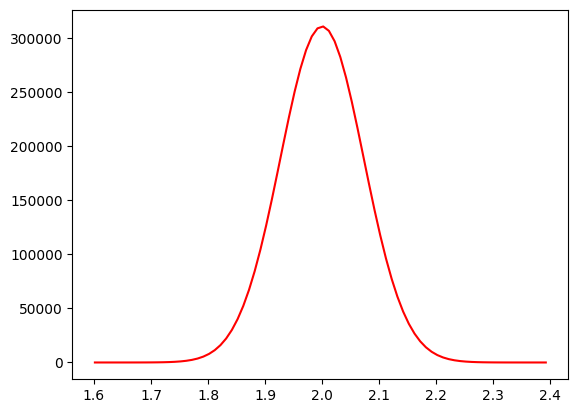

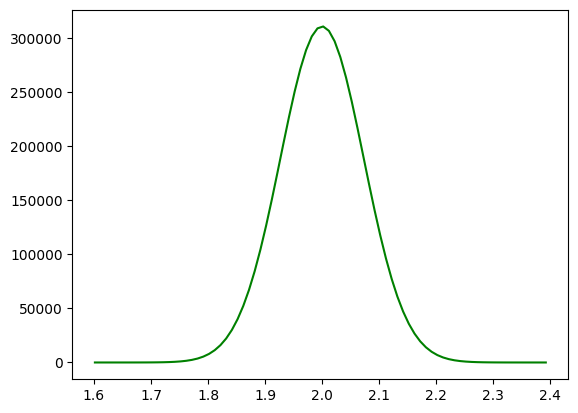

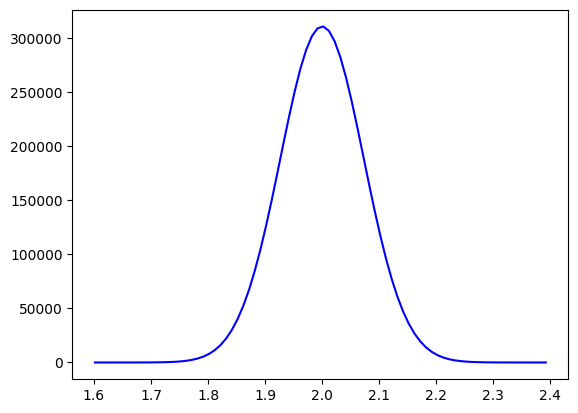

1000
0.01001001001001001
Peaks in PSD1:
Frequency: 2.002002002002002, Value: 310999.5772084767

Peaks in PSD2:
Frequency: 1.8018018018018018, Value: 135629.03661528893

Peaks in PSD3:
Frequency: 1.921921921921922, Value: 149457.745666447


In [24]:
from scipy.stats import norm
from scipy.signal import find_peaks

# Means and standard deviation
means = [2, 4, 6, 8] #young
std_dev = alpha_std

means2 = [1.8] #pachi2005
std_dev2 = [0.11]

means3 = [1.92] #sahanaci2011
std_dev3 = [0.13]   

# Generate x values
x = np.linspace(0, 10, 1000)

# Initialize a combined PDF array with zeros
combined_pdf = np.zeros_like(x)
combined_pdf2 = np.zeros_like(x)
combined_pdf3 = np.zeros_like(x)

# Plot each normal PDF
for i in range (np.size(means)):
    pdf = norm.pdf(x, means[i], std_dev[i])
    alpha = ((80*9.81*mean_alpha[i])**2)/2
    combined_pdf += pdf*alpha
 
for i in range (np.size(means2)):
    pdf2 = norm.pdf(x, means2[i], std_dev2[i])
    mean_pace=means2[i]
    alpha2 = ((80*9.81*0.41 * (mean_pace - 0.95))**2)/2
    combined_pdf2 += pdf2*alpha2

for i in range (np.size(means3)):
    pdf3 = norm.pdf(x, means3[i], std_dev3[i])
    mean_pace=means3[i]
    
    alpha3 = ((80*9.81*0.41 * (mean_pace - 0.95))**2)/2
    print(mean_alpha[i])
    combined_pdf3 += pdf3*alpha3


frequencies = np.array(x)
psd1 = np.array(combined_pdf)
psd2 = np.array(combined_pdf2)
psd3 = np.array(combined_pdf3)

selected_indices = (frequencies >= 1.6) & (frequencies <= 2.4)
frequencies_selected = frequencies[selected_indices]

psd1= psd1[selected_indices]
psd2= psd2[selected_indices]
psd3= psd3[selected_indices]

# Plot the combined PDF
plt.plot(frequencies_selected, psd1, label='mean 2 harmonic 1', color='red', )
plt.show()
plt.plot(frequencies_selected, psd1, label='mean 1.8 harmonic 1', color='green', )
plt.show()
plt.plot(frequencies_selected, psd1, label='mean 1.92 harmonic 1', color='blue', )
plt.show()


# Show the plot
plt.show()

print(np.size(frequencies))
print(frequencies[4]-frequencies[3])

# Find peaks in the PSD arrays
peaks_psd1, _ = find_peaks(psd1)
peaks_psd2, _ = find_peaks(psd2)
peaks_psd3, _ = find_peaks(psd3)

# Print the peak frequencies and values
print("Peaks in PSD1:")
for peak in peaks_psd1:
    print(f"Frequency: {frequencies_selected[peak]}, Value: {psd1[peak]}")

print("\nPeaks in PSD2:")
for peak in peaks_psd2:
    print(f"Frequency: {frequencies_selected[peak]}, Value: {psd2[peak]}")

print("\nPeaks in PSD3:")
for peak in peaks_psd3:
    print(f"Frequency: {frequencies_selected[peak]}, Value: {psd3[peak]}")



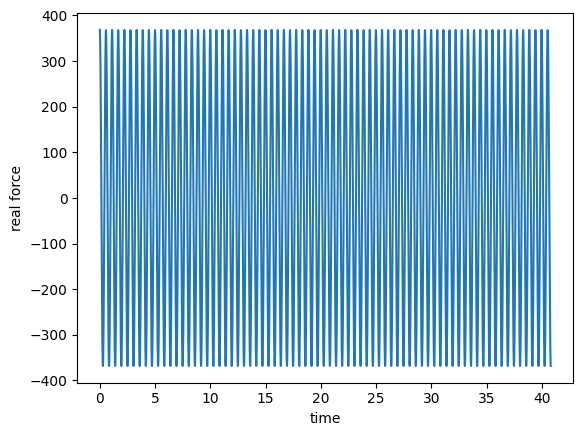

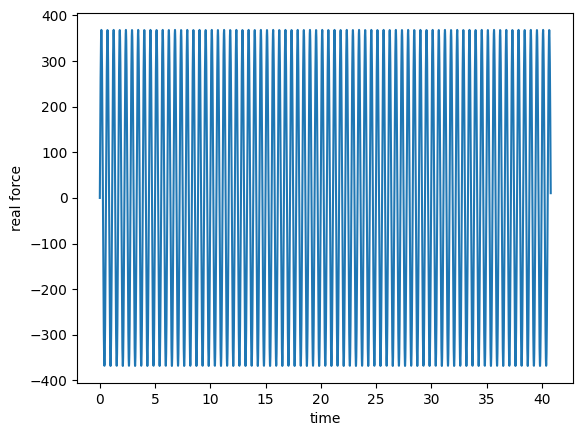

In [25]:
real1,imaginary1 = pseudo_excitation(psd1,frequencies_selected,50,1.25,t)
real2,imaginary2 = pseudo_excitation(psd2,frequencies_selected,50,1.25,t)
real3,imaginary3 = pseudo_excitation(psd3,frequencies_selected,50,1.25,t)
plt.plot(t.flatten(),real2[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()

plt.plot(t.flatten(),imaginary2[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()

In [34]:
Real_responce2 = np.zeros((np.size(frequencies_selected),np.size(t)))
for i in range(np.size(frequencies)):
    realF=np.array(real2[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,realF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    Real_responce2[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)

plt.plot(t.flatten(),Real_responce2[[40],:].T)
plt.xlabel("time")
plt.ylabel("real response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)


[[ 0.00000000e+00  1.14198879e-03  2.25304206e-03 ... -5.06723533e-02
  -6.26073477e-02  0.00000000e+00]
 [ 0.00000000e+00  2.15302100e-03  3.76363680e-03 ... -1.37284865e-03
  -3.05103736e-03  0.00000000e+00]
 [ 0.00000000e+00  2.58681216e-03  2.61893958e-03 ... -1.11593854e-03
  -1.54861079e-03  0.00000000e+00]
 [ 0.00000000e+00  3.70979313e-09  2.58283030e-08 ...  5.17254081e-07
   5.53996173e-08  0.00000000e+00]]
[[ 0.00000000e+00  1.23709503e-03  2.44052138e-03 ... -1.26146081e-02
   3.25074919e-03  0.00000000e+00]
 [ 0.00000000e+00  2.33232726e-03  4.07678149e-03 ...  3.94939741e-04
   2.44422552e-03  0.00000000e+00]
 [ 0.00000000e+00  2.80224508e-03  2.83669289e-03 ...  1.05005631e-03
   1.69798718e-03  0.00000000e+00]
 [ 0.00000000e+00  4.01874930e-09  2.79782972e-08 ... -3.12266258e-06
  -2.61263545e-06  0.00000000e+00]]
[[ 0.00000000e+00  1.33458452e-03  2.63267687e-03 ...  9.99560010e-02
   8.59068139e-02  0.00000000e+00]
 [ 0.00000000e+00  2.51612673e-03  4.39773204e-03 ...

IndexError: index 80 is out of bounds for axis 0 with size 80

In [35]:
import pickle
with open('Real_responce2.pkl', 'wb') as f:
    pickle.dump(Real_responce2, f)

print("Matrix saved to Real_responce2.pkl")

Matrix saved to Real_responce2.pkl


In [36]:
imag_responce2 = np.zeros((np.size(frequencies),np.size(t)))
for i in range(np.size(frequencies)):
    imagF=np.array(imaginary2[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,imagF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    imag_responce2[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)



plt.plot(t.flatten(),imag_responce2[[40],:].T)
plt.xlabel("time")
plt.ylabel("imaginary response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)   


[[ 0.00000000e+00  0.00000000e+00  2.29452513e-04 ...  9.61434358e-02
   8.89627177e-02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  4.32592358e-04 ...  1.27087700e-03
   3.69031853e-04  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  5.19750362e-04 ... -1.11566230e-04
  -5.32638681e-04  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.49076439e-09 ...  3.88258121e-06
   3.76308146e-06  0.00000000e+00]]
[[ 0.00000000e+00  0.00000000e+00  2.50109816e-04 ... -1.23558700e-01
  -1.24289943e-01  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  4.71538070e-04 ... -1.99970972e-03
  -2.27230799e-03  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  5.66542792e-04 ... -6.12427415e-04
  -5.15920413e-04  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.62497592e-09 ... -3.25608174e-06
  -3.45966330e-06  0.00000000e+00]]
[[0.00000000e+00 0.00000000e+00 2.71489878e-04 ... 1.04363521e-01
  1.16335218e-01 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.11846417e-04 ... 2.007145

IndexError: index 80 is out of bounds for axis 0 with size 80

In [37]:
import pickle
with open('imag_responce2.pkl', 'wb') as f:
    pickle.dump(imag_responce2, f)

print("Matrix saved to imag_responce2.pkl")

Matrix saved to imag_responce2.pkl


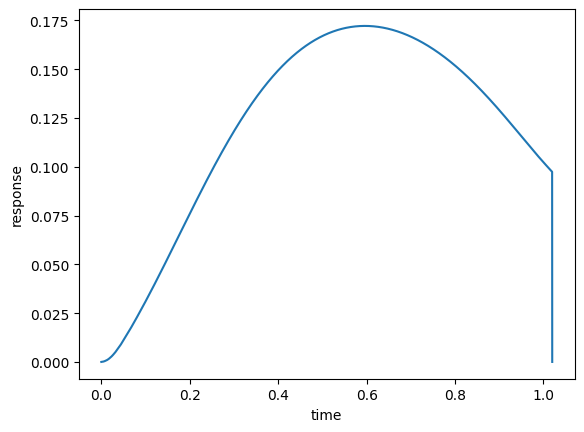

: 

In [39]:
with open('Real_responce2.pkl', 'rb') as f1:
    Real_responce = pickle.load(f1)
with open('imag_responce2.pkl', 'rb') as f2:
    imag_responce = pickle.load(f2)

Y=np.zeros((1,np.size(t)))
delta_f= frequencies[5]-frequencies[4]
for i in range(np.size(t)):
    for j in range(np.size(frequencies_selected)):
        Y[0,[i]] += (Real_responce[[j],[i]]**2 + imag_responce[[j],[i]]**2)*delta_f

deterministic_RMS=np.sqrt(Y)
Xnormal=pedvelocity*t/length

plt.plot(Xnormal.flatten(),deterministic_RMS.T)
plt.xlabel("time")
plt.ylabel("response")

plt.show()